In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 2
rate = 10 
time = 1000
num_samples = 5
t0 = 200

In [4]:
# Simulation control parameters
g_values = [3, 5, 7, 9]

# Network parameters
N_E = 1000
gamma = 0.25
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.5 # changed from 0.1, 0.2 was fine...
C_E = epsilon * N_E # Now 200
C_ext = C_E


# Neuron parameters
tau = 20  * ms # previously 20, tried 50 it was weird, larger numbers more spikes, smaller numbers less spikes
theta = 20  * mV
V_r = 10  * mV
tau_rp = 2  * ms

# Synapse parameters
J = 0.1 * mV     # Previously 0.1 * mV, previouysly 0.075, 0.2 was too varied need to be more consistent
D = 1.5  * ms

# Simulation settings
dt = 0.1  * ms
g = 4 # g is a good control for manipulating the firing rate, smaller numbers more spikes, bigger numbers less spikes
nu_ext_over_nu_thr = 1  # Previously 2, 1.2 was weird, 1 (made 2d plot nice), 0.5 not good,
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

nu_thr = theta / (J * C_E * tau)
nu_ext = nu_ext_over_nu_thr * nu_thr

# adjust g and nu_ext so that nu_ext is approximately the number of spikes that are occuring, influenced by g. 
# epsilon 0.2 and g = 2.6, g = 2.8 is too much,tau = 50
# epsilon 0.5 and g = 4, tau = 20

In [5]:
print(C_E) # C_E and C_ext are the same value

500.0


In [6]:
print(nu_thr)
print(nu_ext)

20. Hz
20. Hz


Generating spike trains, then counting the spikes.

In [8]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([0.1198, 0.139 , 0.2396, 0.4124, 0.6104, 0.7108, 0.7275, 0.7291,
       0.7625, 0.7928, 0.8488, 0.8498, 0.9092]) * second, 1: array([0.0704, 0.1438, 0.1823, 0.3031, 0.3075, 0.576 , 0.6076, 0.6182,
       0.6509, 0.6687, 0.6724, 0.6757, 0.931 ]) * second}, {0: array([0.1534, 0.1601, 0.227 , 0.3655, 0.3819, 0.5589, 0.8748]) * second, 1: array([0.0419, 0.0963, 0.1759, 0.2787, 0.3424, 0.4417, 0.6378, 0.707 ,
       0.791 , 0.9477, 0.9504, 0.9919]) * second}, {0: array([0.2071, 0.3267, 0.4163, 0.4268, 0.6475, 0.7002, 0.9453]) * second, 1: array([0.1479, 0.2768, 0.497 , 0.5461, 0.607 , 0.6146, 0.7204, 0.7503]) * second}, {0: array([  5.8,  18.1,  26.5, 122.4, 192.3, 267.1, 300. , 303. , 340.6,
       447.4, 599.5, 635.7, 638.3, 716.1, 756.1, 817.6, 847.8]) * msecond, 1: array([0.0097, 0.1702, 0.18  , 0.6246, 0.634 , 0.6845, 0.7243, 0.7954,
       0.8225, 0.875 ]) * second}, {0: array([ 55.9, 120.2, 223.6, 408.8, 446.1, 666.9, 678.9, 763.5]) * msecond, 1: array([0.2969, 0.3594, 0.4

In [9]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([0.1198, 0.139 , 0.2396, 0.4124, 0.6104, 0.7108, 0.7275, 0.7291,
       0.7625, 0.7928, 0.8488, 0.8498, 0.9092]) * second, 1: array([0.0704, 0.1438, 0.1823, 0.3031, 0.3075, 0.576 , 0.6076, 0.6182,
       0.6509, 0.6687, 0.6724, 0.6757, 0.931 ]) * second}, {0: array([0.1534, 0.1601, 0.227 , 0.3655, 0.3819, 0.5589, 0.8748]) * second, 1: array([0.0419, 0.0963, 0.1759, 0.2787, 0.3424, 0.4417, 0.6378, 0.707 ,
       0.791 , 0.9477, 0.9504, 0.9919]) * second}, {0: array([0.2071, 0.3267, 0.4163, 0.4268, 0.6475, 0.7002, 0.9453]) * second, 1: array([0.1479, 0.2768, 0.497 , 0.5461, 0.607 , 0.6146, 0.7204, 0.7503]) * second}, {0: array([  5.8,  18.1,  26.5, 122.4, 192.3, 267.1, 300. , 303. , 340.6,
       447.4, 599.5, 635.7, 638.3, 716.1, 756.1, 817.6, 847.8]) * msecond, 1: array([0.0097, 0.1702, 0.18  , 0.6246, 0.634 , 0.6845, 0.7243, 0.7954,
       0.8225, 0.875 ]) * second}, {0: array([ 55.9, 120.2, 223.6, 408.8, 446.1, 666.9, 678.9, 763.5]) 

In [10]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.1198, 0.139 , 0.2396, 0.4124, 0.6104, 0.7108, 0.7275, 0.7291,
       0.7625, 0.7928, 0.8488, 0.8498, 0.9092]), 1: array([0.0704, 0.1438, 0.1823, 0.3031, 0.3075, 0.576 , 0.6076, 0.6182,
       0.6509, 0.6687, 0.6724, 0.6757, 0.931 ])}, {0: array([0.1534, 0.1601, 0.227 , 0.3655, 0.3819, 0.5589, 0.8748]), 1: array([0.0419, 0.0963, 0.1759, 0.2787, 0.3424, 0.4417, 0.6378, 0.707 ,
       0.791 , 0.9477, 0.9504, 0.9919])}, {0: array([0.2071, 0.3267, 0.4163, 0.4268, 0.6475, 0.7002, 0.9453]), 1: array([0.1479, 0.2768, 0.497 , 0.5461, 0.607 , 0.6146, 0.7204, 0.7503])}, {0: array([0.0058, 0.0181, 0.0265, 0.1224, 0.1923, 0.2671, 0.3   , 0.303 ,
       0.3406, 0.4474, 0.5995, 0.6357, 0.6383, 0.7161, 0.7561, 0.8176,
       0.8478]), 1: array([0.0097, 0.1702, 0.18  , 0.6246, 0.634 , 0.6845, 0.7243, 0.7954,
       0.8225, 0.875 ])}, {0: array([0.0559, 0.1202, 0.2236, 0.4088, 0.4461, 0.6669, 0.6789, 0.7635]), 1: array([0.2969, 0.3594, 0.4247, 0.5012, 0.6136, 0.6198, 0.7255, 0.7306,
      

In [11]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
#print(binary_spikes[0][0])

In [12]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
print(count.shape)

(5, 2, 1000)


In [13]:
spike_rate = count / time * ms
print(spike_rate)

[[[ 0.  0.  0. ... 13. 13. 13.]
  [ 0.  0.  0. ... 13. 13. 13.]]

 [[ 0.  0.  0. ...  7.  7.  7.]
  [ 0.  0.  0. ... 12. 12. 12.]]

 [[ 0.  0.  0. ...  7.  7.  7.]
  [ 0.  0.  0. ...  8.  8.  8.]]

 [[ 0.  0.  0. ... 17. 17. 17.]
  [ 0.  0.  0. ... 10. 10. 10.]]

 [[ 0.  0.  0. ...  8.  8.  8.]
  [ 0.  0.  0. ... 13. 13. 13.]]] us


In [14]:
#print(spike_count[0]) # first sample
print(count[0])

[[ 0.  0.  0. ... 13. 13. 13.]
 [ 0.  0.  0. ... 13. 13. 13.]]


Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [16]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.0527, 0.1004, 0.1442, 0.1948, 0.231 , 0.2567, 0.2876, 0.3093,
       0.3407, 0.3655, 0.3958, 0.4354, 0.4731, 0.506 , 0.537 , 0.5705,
       0.5918, 0.6256, 0.6555, 0.7163, 0.7528, 0.7767, 0.8105, 0.8577,
       0.8921, 0.9349, 0.957 ]) * second, 1: array([0.0591, 0.1024, 0.149 , 0.1913, 0.2332, 0.2839, 0.3434, 0.4014,
       0.4353, 0.4826, 0.5396, 0.5915, 0.6516, 0.6958, 0.7505, 0.7955,
       0.8434, 0.8947, 0.9339, 0.9714]) * second}, {0: array([0.0649, 0.1105, 0.1672, 0.2034, 0.2322, 0.262 , 0.287 , 0.327 ,
       0.3817, 0.4316, 0.4847, 0.507 , 0.5382, 0.5855, 0.6222, 0.6554,
       0.6914, 0.7376, 0.7657, 0.8036, 0.8451, 0.9137, 0.9369, 0.9671]) * second, 1: array([0.0447, 0.1091, 0.1538, 0.2042, 0.2487, 0.2852, 0.3257, 0.3683,
       0.3894, 0.4324, 0.4827, 0.5157, 0.5594, 0.5856, 0.6221, 0.6534,
       0.6901, 0.741 , 0.7931, 0.8349, 0.8908, 0.9319, 0.9658]) * second}, {0: array([0.0461, 0.0876, 0.1237, 0.1601, 0.2034, 0.246 , 0.3153, 0.3568,
       0.3768, 0.4122

In [17]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [18]:
# result = vary_g(sim, g_values)

In [19]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.0527, 0.1004, 0.1442, 0.1948, 0.231 , 0.2567, 0.2876, 0.3093,
       0.3407, 0.3655, 0.3958, 0.4354, 0.4731, 0.506 , 0.537 , 0.5705,
       0.5918, 0.6256, 0.6555, 0.7163, 0.7528, 0.7767, 0.8105, 0.8577,
       0.8921, 0.9349, 0.957 ]), 1: array([0.0591, 0.1024, 0.149 , 0.1913, 0.2332, 0.2839, 0.3434, 0.4014,
       0.4353, 0.4826, 0.5396, 0.5915, 0.6516, 0.6958, 0.7505, 0.7955,
       0.8434, 0.8947, 0.9339, 0.9714])}
{0: array([0.0578, 0.1031, 0.1503, 0.1948, 0.2378, 0.2813, 0.3313, 0.3915,
       0.4122, 0.4379, 0.4806, 0.519 , 0.544 , 0.5932, 0.632 , 0.6582,
       0.7192, 0.7558, 0.8095, 0.8624, 0.906 , 0.9431, 0.9972]), 1: array([0.0577, 0.1004, 0.1401, 0.2291, 0.2821, 0.3213, 0.3655, 0.4021,
       0.432 , 0.475 , 0.5416, 0.5918, 0.6264, 0.6571, 0.6949, 0.7214,
       0.7612, 0.8088, 0.8576, 0.8927, 0.931 , 0.9683])}


In [20]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

# print(binary_ex_spikes[0][0]) # first sample of first neuron

In [21]:
spike_count_ex = count_spikes(binary_ex_spikes)
#print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex[1])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[[ 0.  0.  0. ... 27. 27. 27.]
 [ 0.  0.  0. ... 20. 20. 20.]]
[[ 0.  0.  0. ... 24. 24. 24.]
 [ 0.  0.  0. ... 23. 23. 23.]]
(5, 2, 1000)
(5, 2, 1000)


In [22]:
spike_rate_ex = count_ex / time * ms
spike_rate_in = count_in / time * ms
print(spike_rate_ex)
print(spike_rate_in)

[[[ 0.  0.  0. ... 27. 27. 27.]
  [ 0.  0.  0. ... 20. 20. 20.]]

 [[ 0.  0.  0. ... 24. 24. 24.]
  [ 0.  0.  0. ... 23. 23. 23.]]

 [[ 0.  0.  0. ... 23. 23. 23.]
  [ 0.  0.  0. ... 20. 20. 20.]]

 [[ 0.  0.  0. ... 22. 22. 22.]
  [ 0.  0.  0. ... 23. 23. 23.]]

 [[ 0.  0.  0. ... 26. 26. 26.]
  [ 0.  0.  0. ... 21. 21. 21.]]] us
[[[ 0.  0.  0. ... 23. 23. 23.]
  [ 0.  0.  0. ... 22. 22. 22.]]

 [[ 0.  0.  0. ... 19. 19. 19.]
  [ 0.  0.  0. ... 22. 22. 22.]]

 [[ 0.  0.  0. ... 21. 21. 21.]
  [ 0.  0.  0. ... 21. 21. 21.]]

 [[ 0.  0.  0. ... 18. 18. 18.]
  [ 0.  0.  0. ... 18. 18. 18.]]

 [[ 0.  0.  0. ... 21. 21. 21.]
  [ 0.  0.  0. ... 17. 17. 17.]]] us


Theoretical and Empirical stats of raw counts.

In [24]:
theoretical_means = calculate_theoretical_mean(rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.   0.01 0.02 ... 9.97 9.98 9.99]
 [0.   0.01 0.02 ... 9.97 9.98 9.99]]
(2, 1000)
[[0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]
 [0.         0.1        0.14142136 ... 3.15753068 3.1591138  3.16069613]]
(2, 1000)


In [25]:
empirical_mean = empirical_means(count)
print(empirical_mean)
print(empirical_mean.shape)

empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[ 0.   0.   0.  ... 10.4 10.4 10.4]
 [ 0.   0.   0.  ... 11.2 11.2 11.2]]
(2, 1000)
[[0.         0.         0.         ... 4.44971909 4.44971909 4.44971909]
 [0.         0.         0.         ... 2.16794834 2.16794834 2.16794834]]
(2, 1000)


In [26]:
res_var = variance_of_residuals(empirical_mean, theoretical_means)
print(res_var)

0.4587885842921461


Theoretical and Empirical stats of excitatory counts.

In [28]:
theoretical_means_sim = calculate_theoretical_mean(nu_ext, time)
print(theoretical_means_sim)
print(theoretical_means_sim.shape)

theoretical_std_dev_sim = calculate_theoretical_std_dev(theoretical_means_sim)
print(theoretical_std_dev_sim)
print(theoretical_std_dev_sim.shape)

theoretical_lower_bound_sim, theoretical_upper_bound_sim = confidence_intervals(theoretical_means_sim, theoretical_std_dev_sim, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[ 0.    0.02  0.04 ... 19.94 19.96 19.98]
 [ 0.    0.02  0.04 ... 19.94 19.96 19.98]]
(2, 1000)
[[0.         0.14142136 0.2        ... 4.46542271 4.46766158 4.46989933]
 [0.         0.14142136 0.2        ... 4.46542271 4.46766158 4.46989933]]
(2, 1000)


In [29]:
empirical_mean_ex = empirical_means(count_ex)
print(empirical_mean_ex)
print(empirical_mean_ex.shape)

empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

[[ 0.   0.   0.  ... 24.4 24.4 24.4]
 [ 0.   0.   0.  ... 21.4 21.4 21.4]]
(2, 1000)
[[0.         0.         0.         ... 2.07364414 2.07364414 2.07364414]
 [0.         0.         0.         ... 1.51657509 1.51657509 1.51657509]]
(2, 1000)


In [30]:
res_var_ex = variance_of_residuals(empirical_mean_ex, theoretical_means_sim)
print(res_var_ex)

2.5057431115557782


Theoretical and Empirical stats of inhibitory counts.

In [32]:
empirical_mean_in = empirical_means(count_in)
print(empirical_mean_in)
print(empirical_mean_in.shape)

empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

[[ 0.   0.   0.  ... 20.4 20.4 20.4]
 [ 0.   0.   0.  ... 20.  20.  20. ]]
(2, 1000)
[[0.         0.         0.         ... 1.94935887 1.94935887 1.94935887]
 [0.         0.         0.         ... 2.34520788 2.34520788 2.34520788]]
(2, 1000)


In [33]:
res_var_in = variance_of_residuals(empirical_mean_in, theoretical_means_sim)
print(res_var_in)

0.12300294147073532


Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

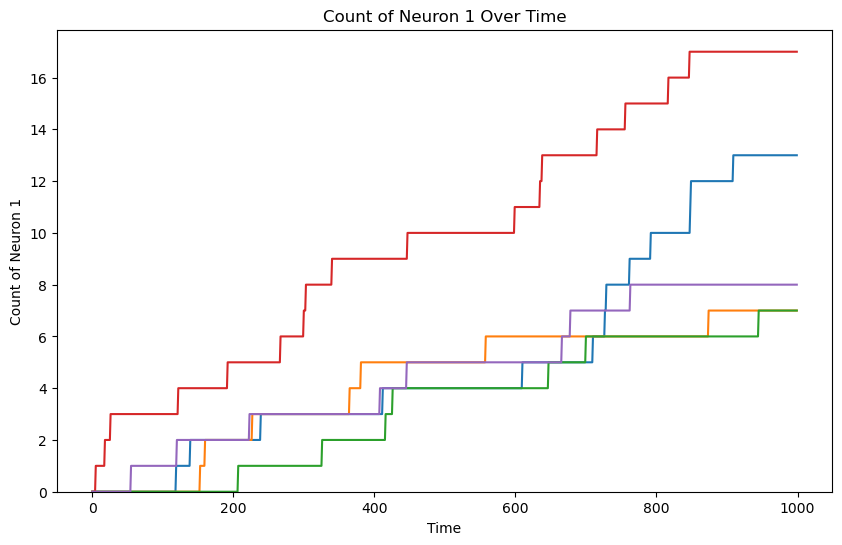

In [35]:
plot_count_neuron1_vs_time(count, num_samples)

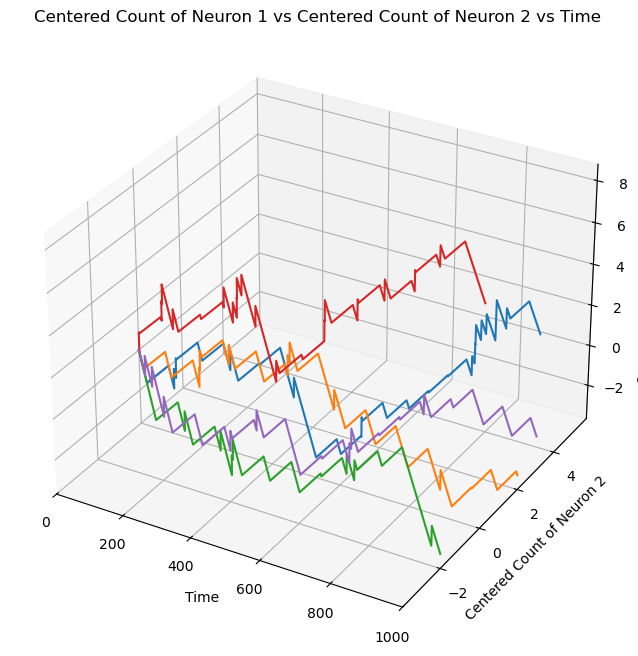

In [36]:
plot_centered_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev)

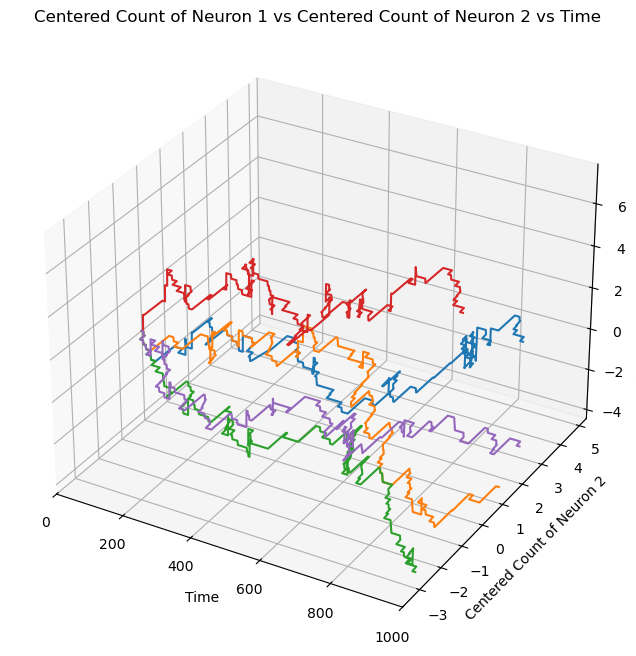

In [37]:
plot_centered_staircase_3d(count, num_samples, empirical_mean, empirical_std_dev)

In [38]:
#plot_standardized_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev, t0)

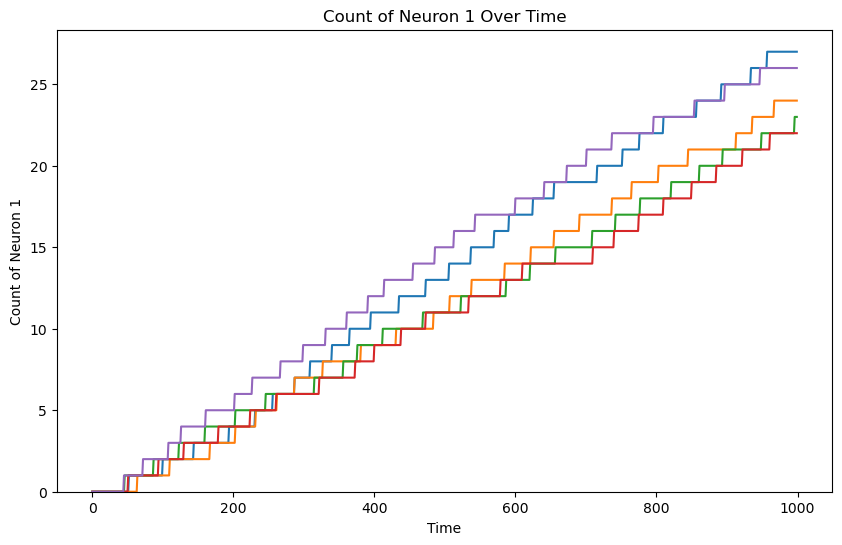

In [39]:
plot_count_neuron1_vs_time(count_ex, num_samples)

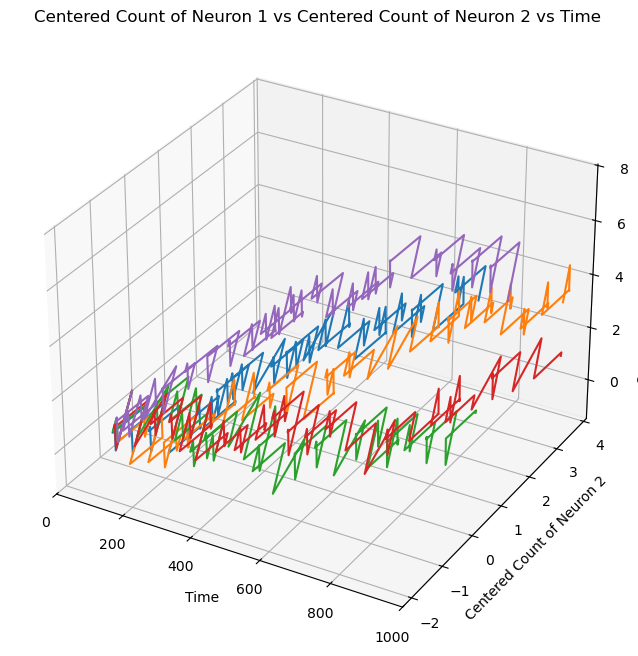

In [40]:
plot_centered_staircase_3d(count_ex, num_samples, theoretical_means_sim, theoretical_std_dev_sim)

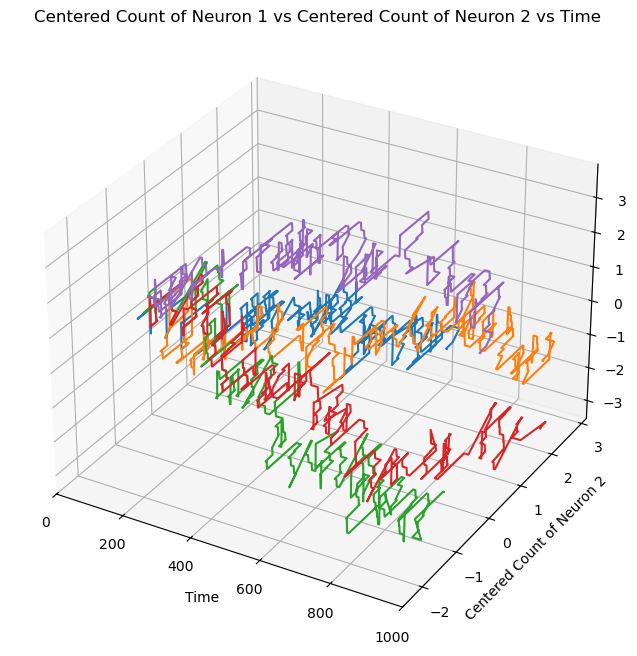

In [41]:
plot_centered_staircase_3d(count_ex, num_samples, empirical_mean_ex, empirical_std_dev_ex)

In [42]:
# plot_standardized_staircase_3d(count_ex, num_samples, theoretical_means_sim, theoretical_std_dev_sim, t0)

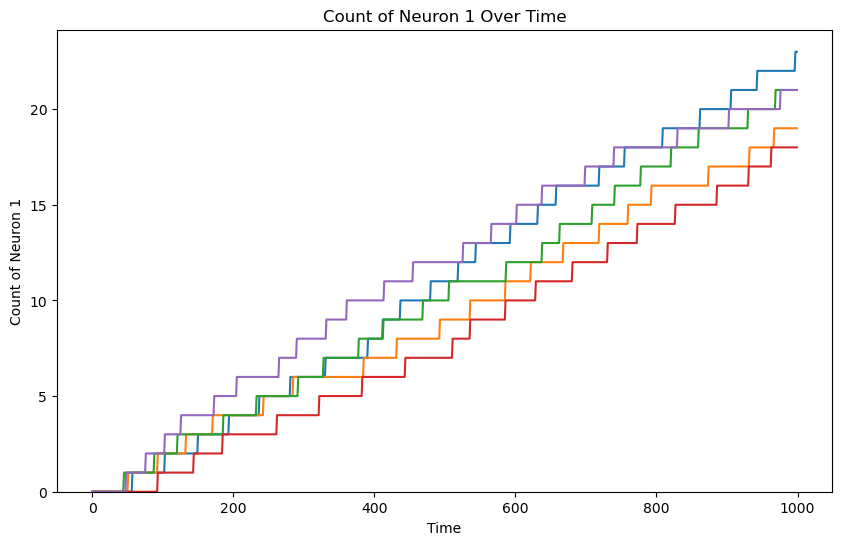

In [43]:
plot_count_neuron1_vs_time(count_in, num_samples)

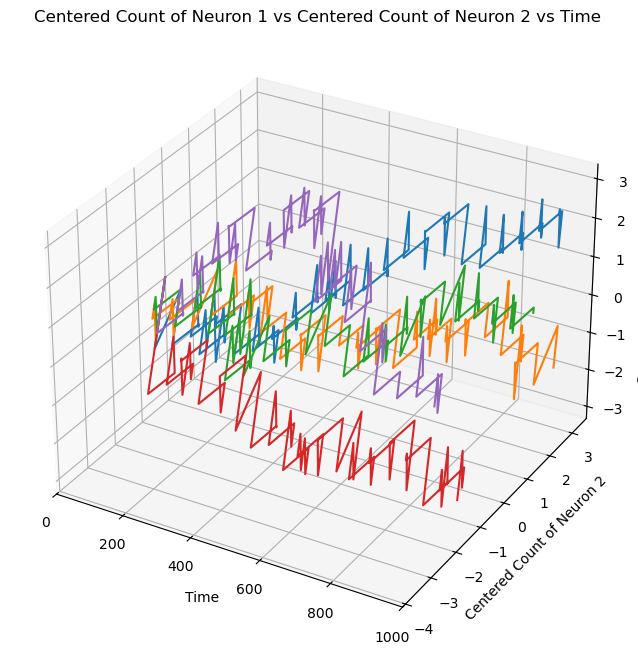

In [44]:
plot_centered_staircase_3d(count_in, num_samples, theoretical_means_sim, theoretical_std_dev_sim)

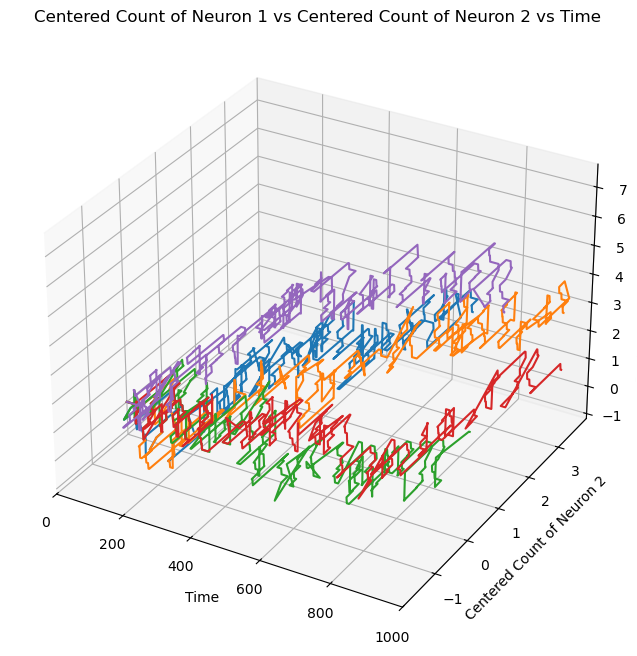

In [45]:
plot_centered_staircase_3d(count_ex, num_samples, empirical_mean_in, empirical_std_dev_in)

In [46]:
# plot_standardized_staircase_3d(count_in, num_samples, theoretical_means_sim, theoretical_std_dev_sim, t0)

In [47]:
print(f"Threshold rate: {nu_thr:.2f} Hz")
print(f"External rate: {nu_ext:.2f} Hz")
print(f"Theoretical mean at t={time}: {theoretical_means_sim[0,-1]:.2f}")
print(f"Empirical mean: {empirical_mean_ex}")

Threshold rate: 20.00 Hz
External rate: 20.00 Hz
Theoretical mean at t=1000: 19.98
Empirical mean: [[ 0.   0.   0.  ... 24.4 24.4 24.4]
 [ 0.   0.   0.  ... 21.4 21.4 21.4]]
